In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 1: Setup — Mount Drive & Install Dependencies             ║
# ╚═══════════════════════════════════════════════════════════════════╝

from google.colab import drive
drive.mount('/content/drive')

!pip install -q python-docx matplotlib requests

import json
import glob
import os
import sys
import io
import hashlib
from datetime import datetime, timedelta
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

from docx import Document
from docx.shared import Inches, Pt, Cm, RGBColor, Emu
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml.ns import qn

import requests

print("✅ All dependencies loaded and Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All dependencies loaded and Drive mounted.


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 2: Configuration — Edit these paths if needed             ║
# ╚═══════════════════════════════════════════════════════════════════╝

# ── CHANGE THESE IF YOUR FOLDER IS SOMEWHERE ELSE ───────────────────
LOG_FOLDER   = "/content/drive/MyDrive/Honeypot Project/cowrie_logs"
OUTPUT_FILE  = "/content/drive/MyDrive/Honeypot Project/cowrie_threat_report.docx"
CHART_DIR    = "/content/drive/MyDrive/Honeypot Project/cowrie_charts"

# Options
ENABLE_GEOIP = True   # Set False to skip GeoIP lookups (faster, no network)
TOP_N        = 20      # Number of top items per category

os.makedirs(CHART_DIR, exist_ok=True)

# Verify the log folder exists
if not os.path.isdir(LOG_FOLDER):
    raise FileNotFoundError(
        f"❌ Folder not found: {LOG_FOLDER}\n"
        f"   Make sure 'cowrie_logs' exists in the root of your Google Drive.\n"
        f"   If it's nested, update LOG_FOLDER above."
    )

# Show what's in the folder
files_found = sorted(os.listdir(LOG_FOLDER))
print(f"📂 Found {len(files_found)} file(s) in {LOG_FOLDER}:")
for f in files_found[:20]:
    size_mb = os.path.getsize(os.path.join(LOG_FOLDER, f)) / (1024*1024)
    print(f"   {f}  ({size_mb:.1f} MB)")
if len(files_found) > 20:
    print(f"   ... and {len(files_found) - 20} more")

📂 Found 183 file(s) in /content/drive/MyDrive/Honeypot Project/cowrie_logs:
   .gitignore  (0.0 MB)
   cowrie.json  (0.3 MB)
   cowrie.json.2025-09-10  (0.0 MB)
   cowrie.json.2025-09-11  (0.2 MB)
   cowrie.json.2025-09-12  (0.1 MB)
   cowrie.json.2025-09-13  (0.0 MB)
   cowrie.json.2025-09-14  (0.0 MB)
   cowrie.json.2025-09-15  (0.2 MB)
   cowrie.json.2025-09-16  (0.3 MB)
   cowrie.json.2025-09-17  (0.1 MB)
   cowrie.json.2025-09-18  (0.0 MB)
   cowrie.json.2025-09-19  (0.1 MB)
   cowrie.json.2025-09-20  (0.1 MB)
   cowrie.json.2025-09-21  (0.1 MB)
   cowrie.json.2025-09-22  (0.1 MB)
   cowrie.json.2025-09-23  (0.1 MB)
   cowrie.json.2025-09-24  (0.1 MB)
   cowrie.json.2025-09-25  (0.1 MB)
   cowrie.json.2025-09-26  (0.5 MB)
   cowrie.json.2025-09-27  (0.1 MB)
   ... and 163 more


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 3: Log Parser                                             ║
# ╚═══════════════════════════════════════════════════════════════════╝

def parse_cowrie_logs(folder: str) -> list:
    """Parse all JSON log files in the given folder."""
    events = []
    log_files = []

    p = Path(folder)
    for pattern in ["cowrie.json*", "*.json", "*.log"]:
        log_files.extend(p.glob(pattern))
    log_files = sorted(set(log_files))

    if not log_files:
        raise FileNotFoundError(f"No .json or .log files found in {folder}")

    print(f"\n🔍 Parsing {len(log_files)} log file(s)...")

    for f in log_files:
        line_count = 0
        error_count = 0
        with open(f, "r", errors="replace") as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                try:
                    event = json.loads(line)
                    events.append(event)
                    line_count += 1
                except json.JSONDecodeError:
                    error_count += 1
        status = f"   ✓ {f.name}: {line_count:,} events"
        if error_count:
            status += f" ({error_count} bad lines skipped)"
        print(status)

    print(f"\n📊 Total events parsed: {len(events):,}")
    return events


events = parse_cowrie_logs(LOG_FOLDER)


🔍 Parsing 182 log file(s)...
   ✓ cowrie.json: 518 events
   ✓ cowrie.json.2025-09-10: 22 events
   ✓ cowrie.json.2025-09-11: 332 events
   ✓ cowrie.json.2025-09-12: 143 events
   ✓ cowrie.json.2025-09-13: 92 events
   ✓ cowrie.json.2025-09-14: 110 events
   ✓ cowrie.json.2025-09-15: 339 events
   ✓ cowrie.json.2025-09-16: 652 events
   ✓ cowrie.json.2025-09-17: 143 events
   ✓ cowrie.json.2025-09-18: 102 events
   ✓ cowrie.json.2025-09-19: 266 events
   ✓ cowrie.json.2025-09-20: 125 events
   ✓ cowrie.json.2025-09-21: 202 events
   ✓ cowrie.json.2025-09-22: 199 events
   ✓ cowrie.json.2025-09-23: 122 events
   ✓ cowrie.json.2025-09-24: 149 events
   ✓ cowrie.json.2025-09-25: 148 events
   ✓ cowrie.json.2025-09-26: 1,053 events
   ✓ cowrie.json.2025-09-27: 182 events
   ✓ cowrie.json.2025-09-28: 155 events
   ✓ cowrie.json.2025-09-29: 440 events
   ✓ cowrie.json.2025-09-30: 80 events
   ✓ cowrie.json.2025-10-01: 1,988 events
   ✓ cowrie.json.2025-10-02: 4,740 events
   ✓ cowrie.json.2

In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 4: Analyzer Engine                                        ║
# ╚═══════════════════════════════════════════════════════════════════╝

class CowrieAnalyzer:
    """Extracts all metrics from parsed Cowrie events."""

    MITRE_MAP = {
        "cowrie.login.success":           ("T1078", "Valid Accounts",                "Initial Access"),
        "cowrie.login.failed":            ("T1110", "Brute Force",                   "Credential Access"),
        "cowrie.command.input":           ("T1059", "Command & Scripting Interpreter","Execution"),
        "cowrie.session.file_download":   ("T1105", "Ingress Tool Transfer",         "Command & Control"),
        "cowrie.session.file_upload":     ("T1105", "Ingress Tool Transfer",         "Command & Control"),
        "cowrie.direct-tcpip.request":    ("T1572", "Protocol Tunneling",            "Command & Control"),
        "cowrie.client.version":          ("T1595", "Active Scanning",               "Reconnaissance"),
    }

    def __init__(self, events):
        self.events = events
        self.sessions = defaultdict(list)
        for e in events:
            sid = e.get("session")
            if sid:
                self.sessions[sid].append(e)

    def time_range(self):
        timestamps = []
        for e in self.events:
            ts = e.get("timestamp")
            if ts:
                try:
                    timestamps.append(datetime.fromisoformat(ts.replace("Z", "+00:00")))
                except (ValueError, TypeError):
                    pass
        if not timestamps:
            return (datetime.now(), datetime.now())
        return (min(timestamps), max(timestamps))

    def top_source_ips(self, n=20):
        ips = Counter()
        for e in self.events:
            ip = e.get("src_ip")
            if ip:
                ips[ip] += 1
        return ips.most_common(n)

    def top_credentials(self, n=25):
        creds = Counter()
        for e in self.events:
            if "login" in e.get("eventid", ""):
                u = e.get("username", "")
                p = e.get("password", "")
                if u or p:
                    creds[(u, p)] += 1
        return creds.most_common(n)

    def top_usernames(self, n=15):
        users = Counter()
        for e in self.events:
            if "login" in e.get("eventid", ""):
                u = e.get("username", "")
                if u:
                    users[u] += 1
        return users.most_common(n)

    def top_passwords(self, n=15):
        pwds = Counter()
        for e in self.events:
            if "login" in e.get("eventid", ""):
                p = e.get("password", "")
                if p:
                    pwds[p] += 1
        return pwds.most_common(n)

    def login_stats(self):
        success = sum(1 for e in self.events if e.get("eventid") == "cowrie.login.success")
        failed  = sum(1 for e in self.events if e.get("eventid") == "cowrie.login.failed")
        return {"success": success, "failed": failed, "total": success + failed}

    def top_commands(self, n=20):
        cmds = Counter()
        for e in self.events:
            if e.get("eventid") == "cowrie.command.input":
                inp = e.get("input", "").strip()
                if inp:
                    cmds[inp] += 1
        return cmds.most_common(n)

    def command_categories(self):
        categories = defaultdict(int)
        recon_cmds = {"uname","whoami","id","hostname","ifconfig","ip","ls","pwd",
                      "w","who","free","df","nproc","arch","lscpu","uptime","top",
                      "cat","grep","head","awk","wc","which","ls"}
        recon_paths = {"/etc/passwd","/etc/shadow","/proc/cpuinfo","/proc/uptime",
                       "/proc/meminfo","/proc/version"}
        download  = {"wget","curl","tftp","ftp","scp"}
        persist   = {"crontab","useradd","adduser","nohup","screen","tmux"}

        for e in self.events:
            if e.get("eventid") != "cowrie.command.input":
                continue
            cmd = e.get("input", "").strip()
            cmd_lower = cmd.lower()
            if not cmd:
                continue
            first = cmd.split()[0].split("/")[-1].lower() if cmd.split() else ""

            # SSH key injection / authorized_keys manipulation → Persistence
            if ".ssh" in cmd and ("mkdir" in cmd or "echo" in cmd or "authorized_keys" in cmd):
                categories["Persistence"] += 1
            # Crontab writes / scheduled tasks → Persistence
            elif "crontab" in cmd_lower or "/etc/cron" in cmd_lower:
                categories["Persistence"] += 1
            # chmod +x, chown → Persistence (making payloads executable)
            elif first in ("chmod","chown"):
                categories["Persistence"] += 1
            # Downloading files
            elif first in download or "wget " in cmd_lower or "curl " in cmd_lower:
                categories["Malware Download"] += 1
            # Killing security processes, removing logs/scripts → Defense Evasion
            elif first in ("rm","kill","pkill","killall") or "pkill" in cmd_lower:
                categories["Defense Evasion"] += 1
            # PATH manipulation / environment setup
            elif cmd_lower.startswith("export path=") or cmd_lower.startswith("export home="):
                categories["Environment Setup"] += 1
            # System recon commands or reading system files
            elif any(p in cmd_lower for p in recon_paths):
                categories["Reconnaissance"] += 1
            elif first in recon_cmds and len(cmd) < 80:
                categories["Reconnaissance"] += 1
            # Lateral movement
            elif first in ("ssh","sshpass","nc","ncat","netcat"):
                categories["Lateral Movement"] += 1
            # Script/binary execution
            elif first in ("python","perl","bash","sh","php","./") or cmd.startswith("./"):
                categories["Execution"] += 1
            # cd commands alone
            elif first == "cd":
                categories["Navigation"] += 1
            else:
                categories["Other"] += 1
        return dict(categories)

    def file_downloads(self):
        downloads = []
        seen_hashes = set()
        for e in self.events:
            if e.get("eventid") in ("cowrie.session.file_download","cowrie.session.file_upload"):
                sha = e.get("shasum","N/A")
                # Prefer actual URL; fall back to destfile/filename (not outfile which is just the hash)
                url = e.get("url","")
                if not url:
                    # destfile or filename may have the original name
                    destfile = e.get("destfile", e.get("filename",""))
                    if destfile and not all(c in "0123456789abcdef" for c in destfile.split("/")[-1]):
                        url = destfile.split("/")[-1]
                    else:
                        url = "[binary payload]"
                downloads.append({
                    "url":    url,
                    "sha256": sha,
                    "src_ip": e.get("src_ip","N/A"),
                    "timestamp": e.get("timestamp",""),
                })
        # Deduplicate by sha256+src_ip for the report table
        unique_downloads = []
        for d in downloads:
            key = (d["sha256"], d["src_ip"])
            if key not in seen_hashes:
                seen_hashes.add(key)
                unique_downloads.append(d)
        return unique_downloads

    def extracted_urls(self):
        urls = []
        for e in self.events:
            if e.get("eventid") == "cowrie.command.input":
                cmd = e.get("input","")
                for token in cmd.split():
                    cleaned = token.strip("'\";&|()>{}")
                    if cleaned.startswith("http://") or cleaned.startswith("https://"):
                        # Skip if it's clearly not a URL (no dots)
                        if "." in cleaned.split("://")[1] if "://" in cleaned else False:
                            urls.append(cleaned)
        return urls

    def client_versions(self, n=10):
        versions = Counter()
        for e in self.events:
            if e.get("eventid") == "cowrie.client.version":
                v = e.get("version","")
                if v:
                    versions[v] += 1
        return versions.most_common(n)

    def daily_volume(self):
        daily = defaultdict(int)
        for e in self.events:
            ts = e.get("timestamp","")
            if ts:
                daily[ts[:10]] += 1
        return dict(sorted(daily.items()))

    def event_breakdown(self):
        return dict(Counter(e.get("eventid","unknown") for e in self.events).most_common())

    def session_stats(self):
        durations = []
        for sid, evts in self.sessions.items():
            for e in evts:
                if "duration" in e:
                    try:
                        durations.append(float(e["duration"]))
                    except (ValueError, TypeError):
                        pass
                    break
        if not durations:
            return {"count": len(self.sessions), "avg_duration": 0, "max_duration": 0}
        return {
            "count": len(self.sessions),
            "avg_duration": sum(durations)/len(durations),
            "max_duration": max(durations),
        }

    def mitre_mapping(self):
        results, seen = [], set()
        for e in self.events:
            eid = e.get("eventid","")
            if eid in self.MITRE_MAP and eid not in seen:
                tid, name, tactic = self.MITRE_MAP[eid]
                count = sum(1 for ev in self.events if ev.get("eventid") == eid)
                results.append({"technique_id": tid, "technique_name": name,
                                "tactic": tactic, "event_id": eid, "count": count})
                seen.add(eid)
        return sorted(results, key=lambda x: x["count"], reverse=True)


analyzer = CowrieAnalyzer(events)
start, end = analyzer.time_range()
print(f"\n📅 Date range: {start.strftime('%Y-%m-%d')} → {end.strftime('%Y-%m-%d')}")
print(f"🌐 Unique IPs: {len(set(e.get('src_ip') for e in events if e.get('src_ip'))):,}")
print(f"🔐 Login attempts: {analyzer.login_stats()['total']:,}")
print(f"💻 Sessions: {analyzer.session_stats()['count']:,}")


📅 Date range: 2025-09-10 → 2026-03-10
🌐 Unique IPs: 7,241
🔐 Login attempts: 126,042
💻 Sessions: 139,027


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 5: GeoIP Lookups                                          ║
# ╚═══════════════════════════════════════════════════════════════════╝

def geoip_lookup(ips, max_ips=80):
    results = {}
    batch = ips[:max_ips]
    print(f"🌍 Looking up GeoIP for {len(batch)} IPs...")
    try:
        for i in range(0, len(batch), 100):
            chunk = batch[i:i+100]
            payload = [{"query": ip, "fields": "query,country,countryCode,regionName,city,isp,as,org"}
                       for ip in chunk]
            resp = requests.post(
                "http://ip-api.com/batch?fields=query,country,countryCode,regionName,city,isp,as,org",
                json=payload, timeout=15)
            if resp.status_code == 200:
                for item in resp.json():
                    results[item.get("query","")] = item
    except Exception as e:
        print(f"   ⚠️ GeoIP error: {e}")
    print(f"   ✓ Got data for {len(results)} IPs")
    return results


geo_data = {}
if ENABLE_GEOIP:
    unique_ips = [ip for ip, _ in analyzer.top_source_ips(80)]
    geo_data = geoip_lookup(unique_ips)
else:
    print("⏭️  GeoIP lookups skipped.")

🌍 Looking up GeoIP for 80 IPs...
   ✓ Got data for 80 IPs


📈 Generating charts...
   ✓ Generated 7 chart(s)


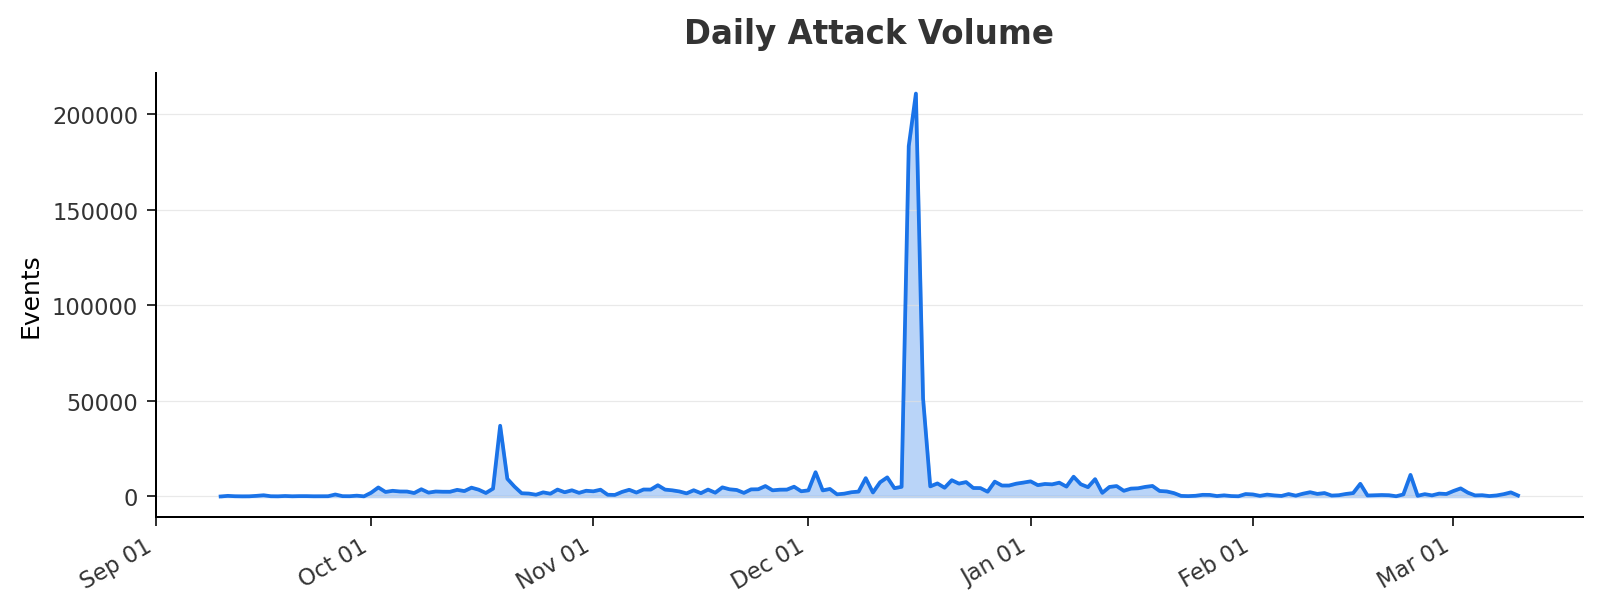

In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 6: Chart Generation                                       ║
# ╚═══════════════════════════════════════════════════════════════════╝

COLORS = {
    "primary": "#1a73e8", "secondary": "#ea4335", "tertiary": "#34a853",
    "quaternary": "#fbbc04", "bg": "#ffffff", "grid": "#e0e0e0", "text": "#333333",
}
BAR_PALETTE = ["#1a73e8","#ea4335","#34a853","#fbbc04","#9c27b0",
               "#ff6d00","#00bcd4","#795548","#607d8b","#e91e63"]

def _setup(fig, ax, title):
    ax.set_title(title, fontsize=13, fontweight="bold", color=COLORS["text"], pad=12)
    ax.tick_params(labelsize=9, colors=COLORS["text"])
    fig.patch.set_facecolor(COLORS["bg"])
    ax.set_facecolor(COLORS["bg"])
    ax.grid(axis="y", color=COLORS["grid"], linewidth=0.5, alpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def chart_daily_volume(daily):
    path = os.path.join(CHART_DIR, "daily_volume.png")
    dates = [datetime.strptime(d, "%Y-%m-%d") for d in daily.keys()]
    counts = list(daily.values())
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.fill_between(dates, counts, alpha=0.3, color=COLORS["primary"])
    ax.plot(dates, counts, color=COLORS["primary"], linewidth=1.5)
    _setup(fig, ax, "Daily Attack Volume")
    ax.set_ylabel("Events", fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.autofmt_xdate(rotation=30)
    plt.tight_layout(); fig.savefig(path, dpi=180, bbox_inches="tight"); plt.close(fig)
    return path

def chart_top_ips(ips):
    path = os.path.join(CHART_DIR, "top_ips.png")
    top = ips[:10]
    labels = [ip for ip, _ in reversed(top)]
    values = [c for _, c in reversed(top)]
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(labels, values, color=BAR_PALETTE[:len(top)])
    _setup(fig, ax, "Top 10 Attacking Source IPs")
    ax.set_xlabel("Number of Events", fontsize=10)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width()+max(values)*0.01, bar.get_y()+bar.get_height()/2,
                f"{val:,}", va="center", fontsize=8)
    plt.tight_layout(); fig.savefig(path, dpi=180, bbox_inches="tight"); plt.close(fig)
    return path

def chart_top_usernames(users):
    path = os.path.join(CHART_DIR, "top_usernames.png")
    top = users[:10]
    labels = [u for u, _ in reversed(top)]
    values = [c for _, c in reversed(top)]
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.barh(labels, values, color=COLORS["secondary"])
    _setup(fig, ax, "Top 10 Attempted Usernames")
    ax.set_xlabel("Attempts", fontsize=10)
    plt.tight_layout(); fig.savefig(path, dpi=180, bbox_inches="tight"); plt.close(fig)
    return path

def chart_top_passwords(passwords):
    path = os.path.join(CHART_DIR, "top_passwords.png")
    top = passwords[:10]
    labels = [p if len(p)<25 else p[:22]+"..." for p, _ in reversed(top)]
    values = [c for _, c in reversed(top)]
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.barh(labels, values, color=COLORS["quaternary"])
    _setup(fig, ax, "Top 10 Attempted Passwords")
    ax.set_xlabel("Attempts", fontsize=10)
    plt.tight_layout(); fig.savefig(path, dpi=180, bbox_inches="tight"); plt.close(fig)
    return path

def chart_command_categories(categories):
    path = os.path.join(CHART_DIR, "cmd_categories.png")
    if not categories: return ""
    # Sort by count descending
    sorted_cats = sorted(categories.items(), key=lambda x: -x[1])
    labels = [c for c, _ in reversed(sorted_cats)]
    values = [v for _, v in reversed(sorted_cats)]
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(labels, values, color=BAR_PALETTE[:len(labels)])
    _setup(fig, ax, "Post-Compromise Command Categories")
    ax.set_xlabel("Count", fontsize=10)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + max(values)*0.01, bar.get_y() + bar.get_height()/2,
                f"{val:,}", va="center", fontsize=8)
    plt.tight_layout(); fig.savefig(path, dpi=180, bbox_inches="tight"); plt.close(fig)
    return path

def chart_login_pie(stats):
    path = os.path.join(CHART_DIR, "login_stats.png")
    fig, ax = plt.subplots(figsize=(5, 3.5))
    ax.pie([stats["failed"], stats["success"]], labels=["Failed","Successful"],
           autopct="%1.1f%%", colors=[COLORS["secondary"], COLORS["tertiary"]],
           textprops={"fontsize":10}, startangle=90)
    ax.set_title("Login Attempts: Success vs Failure", fontsize=13,
                 fontweight="bold", color=COLORS["text"], pad=12)
    fig.patch.set_facecolor(COLORS["bg"])
    plt.tight_layout(); fig.savefig(path, dpi=180, bbox_inches="tight"); plt.close(fig)
    return path

def chart_country_dist(geo_data, ip_counts):
    path = os.path.join(CHART_DIR, "country_dist.png")
    country_counts = Counter()
    ip_map = dict(ip_counts)
    for ip, info in geo_data.items():
        country_counts[info.get("country","Unknown")] += ip_map.get(ip, 1)
    if not country_counts: return ""
    top = country_counts.most_common(10)
    labels = [c for c, _ in reversed(top)]
    values = [v for _, v in reversed(top)]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(labels, values, color=COLORS["tertiary"])
    _setup(fig, ax, "Top 10 Attack Source Countries")
    ax.set_xlabel("Events", fontsize=10)
    plt.tight_layout(); fig.savefig(path, dpi=180, bbox_inches="tight"); plt.close(fig)
    return path


# Generate all charts
print("📈 Generating charts...")
charts = {}
daily = analyzer.daily_volume()
top_ips = analyzer.top_source_ips(TOP_N)
top_users = analyzer.top_usernames(15)
top_pwds = analyzer.top_passwords(15)
cmd_cats = analyzer.command_categories()
login_stats = analyzer.login_stats()

if daily:          charts["daily"]     = chart_daily_volume(daily)
if top_ips:        charts["ips"]       = chart_top_ips(top_ips)
if top_users:      charts["users"]     = chart_top_usernames(top_users)
if top_pwds:       charts["passwords"] = chart_top_passwords(top_pwds)
if cmd_cats:       charts["cmd_cats"]  = chart_command_categories(cmd_cats)
if login_stats["total"]: charts["login"] = chart_login_pie(login_stats)
if geo_data:
    c = chart_country_dist(geo_data, top_ips)
    if c: charts["country"] = c

print(f"   ✓ Generated {len(charts)} chart(s)")

# Preview the daily volume chart inline
if "daily" in charts:
    from IPython.display import display, Image
    display(Image(filename=charts["daily"], width=700))

In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 7: Generate Word Report                                   ║
# ╚═══════════════════════════════════════════════════════════════════╝

def set_cell_shading(cell, color_hex):
    shading = cell._element.get_or_add_tcPr()
    shading_elem = shading.makeelement(qn("w:shd"), {qn("w:fill"): color_hex, qn("w:val"): "clear"})
    shading.append(shading_elem)

def add_table(doc, headers, rows, col_widths=None):
    table = doc.add_table(rows=1, cols=len(headers))
    table.alignment = WD_TABLE_ALIGNMENT.CENTER
    table.style = "Table Grid"
    for i, h in enumerate(headers):
        cell = table.rows[0].cells[i]
        cell.text = h
        for p in cell.paragraphs:
            for r in p.runs:
                r.bold = True; r.font.size = Pt(9)
                r.font.color.rgb = RGBColor(0xFF,0xFF,0xFF)
        set_cell_shading(cell, "1a73e8")
    for rd in rows:
        row = table.add_row()
        for i, val in enumerate(rd):
            row.cells[i].text = str(val)
            for p in row.cells[i].paragraphs:
                for r in p.runs: r.font.size = Pt(9)
    if col_widths:
        for row in table.rows:
            for i, w in enumerate(col_widths):
                row.cells[i].width = Inches(w)
    return table


print("📝 Building Word report...")

doc = Document()

# Styles
style = doc.styles["Normal"]
style.font.name = "Calibri"; style.font.size = Pt(11)
style.font.color.rgb = RGBColor(0x33,0x33,0x33)
for lvl, sz in [(1,18),(2,14),(3,12)]:
    h = doc.styles[f"Heading {lvl}"]
    h.font.name = "Calibri"; h.font.size = Pt(sz)
    h.font.color.rgb = RGBColor(0x1A,0x73,0xE8); h.font.bold = True

# Gather data
total_events = len(events)
unique_ips = len(set(e.get("src_ip") for e in events if e.get("src_ip")))
top_creds = analyzer.top_credentials(25)
top_cmds = analyzer.top_commands(TOP_N)
downloads = analyzer.file_downloads()
total_dl_count = sum(1 for e in events if e.get("eventid") in ("cowrie.session.file_download","cowrie.session.file_upload"))
extracted_urls = analyzer.extracted_urls()
client_vers = analyzer.client_versions(10)
event_types = analyzer.event_breakdown()
sess_stats = analyzer.session_stats()
mitre = analyzer.mitre_mapping()
days_span = (end - start).days + 1

# ── Title Page ──────────────────────────────────────────────────────
for _ in range(6): doc.add_paragraph("")
title = doc.add_paragraph()
title.alignment = WD_ALIGN_PARAGRAPH.CENTER
run = title.add_run("COWRIE HONEYPOT\nTHREAT INTELLIGENCE REPORT")
run.font.size = Pt(28); run.font.color.rgb = RGBColor(0x1A,0x73,0xE8); run.bold = True

sub = doc.add_paragraph()
sub.alignment = WD_ALIGN_PARAGRAPH.CENTER
run = sub.add_run(f"\n{start.strftime('%B %d, %Y')} — {end.strftime('%B %d, %Y')}")
run.font.size = Pt(14); run.font.color.rgb = RGBColor(0x66,0x66,0x66)

meta = doc.add_paragraph()
meta.alignment = WD_ALIGN_PARAGRAPH.CENTER
run = meta.add_run(f"\nGenerated: {datetime.now().strftime('%Y-%m-%d %H:%M')}\nAuthor: Sai Krishna Masetti")
run.font.size = Pt(11); run.font.color.rgb = RGBColor(0x99,0x99,0x99)
doc.add_page_break()

# ── TOC ─────────────────────────────────────────────────────────────
doc.add_heading("Table of Contents", level=1)
for item in ["1. Executive Summary","2. Attack Volume & Trends","3. Source IP Analysis",
             "4. Geographic Distribution","5. Credential Analysis","6. Post-Compromise Activity",
             "7. Malware & Payload Analysis","8. SSH Client Fingerprinting",
             "9. MITRE ATT&CK Mapping","10. Recommendations"]:
    doc.add_paragraph(item)
doc.add_page_break()

# ── 1. Executive Summary ────────────────────────────────────────────
doc.add_heading("1. Executive Summary", level=1)
doc.add_paragraph(
    f"This report presents the analysis of {total_events:,} events collected by a Cowrie SSH/Telnet "
    f"honeypot over a {days_span}-day period from {start.strftime('%B %d, %Y')} to "
    f"{end.strftime('%B %d, %Y')}. The honeypot recorded activity from {unique_ips:,} unique "
    f"source IP addresses across {sess_stats['count']:,} sessions.")
doc.add_heading("Key Findings", level=2)
add_table(doc, ["Metric","Value"], [
    ["Total Events", f"{total_events:,}"],
    ["Date Range", f"{start.strftime('%Y-%m-%d')} to {end.strftime('%Y-%m-%d')} ({days_span} days)"],
    ["Unique Source IPs", f"{unique_ips:,}"],
    ["Total Sessions", f"{sess_stats['count']:,}"],
    ["Login Attempts", f"{login_stats['total']:,}"],
    ["Successful Logins", f"{login_stats['success']:,}"],
    ["Failed Logins", f"{login_stats['failed']:,}"],
    ["File Downloads (total)", f"{total_dl_count:,}"],
    ["Unique Malware Samples", f"{len(downloads):,}"],
    ["Avg Session Duration", f"{sess_stats['avg_duration']:.1f} sec"],
], col_widths=[3.5,3.5])
doc.add_paragraph(""); doc.add_page_break()

# ── 2. Attack Volume ────────────────────────────────────────────────
doc.add_heading("2. Attack Volume & Trends", level=1)
if daily:
    avg_daily = total_events / max(days_span,1)
    peak = max(daily.items(), key=lambda x: x[1])
    doc.add_paragraph(
        f"The honeypot averaged {avg_daily:,.0f} events per day. "
        f"Peak day was {peak[0]} with {peak[1]:,} events.")
    if "daily" in charts:
        doc.add_picture(charts["daily"], width=Inches(6.2))
        doc.add_paragraph("")
doc.add_heading("Event Type Breakdown", level=2)
add_table(doc, ["Event ID","Count"],
          [[eid, f"{c:,}"] for eid, c in event_types.items()][:15],
          col_widths=[4.0,2.0])
doc.add_paragraph(""); doc.add_page_break()

# ── 3. Source IP Analysis ───────────────────────────────────────────
doc.add_heading("3. Source IP Analysis", level=1)
doc.add_paragraph(f"{unique_ips:,} unique IPs observed. Top 15 most active:")
ip_rows = []
for ip, count in top_ips[:15]:
    geo = geo_data.get(ip, {})
    ip_rows.append([ip, f"{count:,}", geo.get("country","—"), geo.get("isp","—")])
add_table(doc, ["Source IP","Events","Country","ISP"], ip_rows,
          col_widths=[1.8,1.0,1.5,2.7])
doc.add_paragraph("")
if "ips" in charts: doc.add_picture(charts["ips"], width=Inches(5.5))
doc.add_page_break()

# ── 4. Geographic Distribution ──────────────────────────────────────
doc.add_heading("4. Geographic Distribution", level=1)
if geo_data:
    country_counts = Counter()
    ip_map = dict(top_ips)
    for ip, info in geo_data.items():
        country_counts[info.get("country","Unknown")] += ip_map.get(ip,1)
    doc.add_paragraph(f"Attacks from {len(country_counts)} countries. Top source: {country_counts.most_common(1)[0][0]}.")
    add_table(doc, ["Country","Events"],
              [[c, f"{n:,}"] for c, n in country_counts.most_common(15)],
              col_widths=[3.5,2.0])
    doc.add_paragraph("")
    if "country" in charts: doc.add_picture(charts["country"], width=Inches(5.5))
else:
    doc.add_paragraph("GeoIP data not available. Set ENABLE_GEOIP = True and re-run.")
doc.add_page_break()

# ── 5. Credential Analysis ─────────────────────────────────────────
doc.add_heading("5. Credential Analysis", level=1)
doc.add_paragraph(
    f"{login_stats['total']:,} login attempts: {login_stats['success']:,} successful "
    f"({login_stats['success']/max(login_stats['total'],1)*100:.1f}%).")
if "login" in charts:
    doc.add_picture(charts["login"], width=Inches(3.8))
    doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER
    doc.add_paragraph("")
doc.add_heading("Top Username/Password Combinations", level=2)
add_table(doc, ["Username","Password","Attempts"],
          [[u,p,f"{c:,}"] for (u,p),c in top_creds[:20]],
          col_widths=[2.0,2.5,1.2])
doc.add_paragraph("")
if "users" in charts: doc.add_picture(charts["users"], width=Inches(5.0)); doc.add_paragraph("")
if "passwords" in charts: doc.add_picture(charts["passwords"], width=Inches(5.0))
doc.add_page_break()

# ── 6. Post-Compromise Activity ────────────────────────────────────
doc.add_heading("6. Post-Compromise Activity", level=1)
if top_cmds:
    doc.add_paragraph(f"{sum(c for _,c in top_cmds):,} commands captured.")
    doc.add_heading("Top Commands Executed", level=2)
    add_table(doc, ["Command","Count"],
              [[cmd[:67]+"..." if len(cmd)>70 else cmd, f"{c:,}"] for cmd,c in top_cmds[:20]],
              col_widths=[5.0,1.2])
    doc.add_paragraph("")
    if cmd_cats:
        doc.add_heading("Command Intent Categories", level=2)
        add_table(doc, ["Category","Count"],
                  [[cat, f"{c:,}"] for cat,c in sorted(cmd_cats.items(), key=lambda x:-x[1])],
                  col_widths=[3.0,1.5])
        doc.add_paragraph("")
        if "cmd_cats" in charts:
            doc.add_picture(charts["cmd_cats"], width=Inches(5.5))
else:
    doc.add_paragraph("No post-compromise commands observed.")
doc.add_page_break()

# ── 7. Malware & Payload Analysis ──────────────────────────────────
doc.add_heading("7. Malware & Payload Analysis", level=1)
if downloads:
    doc.add_paragraph(f"{total_dl_count:,} file downloads captured ({len(downloads)} unique samples by SHA256+IP):")
    add_table(doc, ["URL / Filename","SHA256 (partial)","Source IP"],
              [[d["url"][:60], d["sha256"][:16]+"...", d["src_ip"]] for d in downloads[:20]],
              col_widths=[3.5,1.8,1.5])
    doc.add_paragraph("")
# Only show actual HTTP URLs, not binary payload labels or hashes
real_urls = [u for u in extracted_urls if u.startswith("http://") or u.startswith("https://")]
if real_urls:
    doc.add_heading("Extracted URLs from Commands", level=2)
    doc.add_paragraph(f"{len(set(real_urls))} unique URLs extracted from attacker commands:")
    for url in sorted(set(real_urls))[:30]:
        p = doc.add_paragraph(url[:120]); p.style.font.size = Pt(9)
elif not downloads:
    doc.add_paragraph("No malware downloads or payload URLs observed.")
doc.add_page_break()

# ── 8. SSH Client Fingerprinting ───────────────────────────────────
doc.add_heading("8. SSH Client Fingerprinting", level=1)
if client_vers:
    doc.add_paragraph("SSH client version strings observed:")
    add_table(doc, ["Client Version","Count"],
              [[v, f"{c:,}"] for v,c in client_vers], col_widths=[4.5,1.5])
else:
    doc.add_paragraph("No SSH client version data captured.")
doc.add_page_break()

# ── 9. MITRE ATT&CK Mapping ────────────────────────────────────────
doc.add_heading("9. MITRE ATT&CK Mapping", level=1)
doc.add_paragraph("MITRE ATT&CK techniques identified from observed activity:")
if mitre:
    add_table(doc, ["Technique ID","Technique","Tactic","Event ID","Count"],
              [[m["technique_id"],m["technique_name"],m["tactic"],m["event_id"],f"{m['count']:,}"]
               for m in mitre],
              col_widths=[1.0,1.8,1.5,1.8,0.7])
else:
    doc.add_paragraph("No mappable TTPs identified.")
doc.add_page_break()

# ── 10. Recommendations ────────────────────────────────────────────
doc.add_heading("10. Recommendations", level=1)
recs = [
    ("Block Prolific Attackers",
     "Implement IP blocklists or rate limiting for top attacking IPs. "
     "Consider fail2ban with aggressive thresholds."),
    ("Strengthen Authentication",
     "Enforce key-based SSH auth, disable password login, use non-standard ports."),
    ("Monitor for Known Malware",
     "Submit captured downloads to VirusTotal. Block malicious URLs at the perimeter."),
    ("Geo-Block Where Appropriate",
     "Block SSH from countries with no legitimate need to connect."),
    ("Expand Honeypot Coverage",
     "Deploy honeypots on HTTP, RDP, SMB ports for broader visibility."),
    ("Integrate with SIEM",
     "Feed logs into Splunk / QRadar / Microsoft Sentinel for real-time alerting."),
    ("Regular Reporting Cadence",
     "Generate this report weekly/monthly to track attacker behavior trends."),
]
for t, d in recs:
    doc.add_heading(t, level=2)
    doc.add_paragraph(d)

# ── Save to Drive ──────────────────────────────────────────────────
doc.save(OUTPUT_FILE)
print(f"\n✅ Report saved to Google Drive: {OUTPUT_FILE}")

# Cleanup temp charts
import shutil
shutil.rmtree(CHART_DIR, ignore_errors=True)

📝 Building Word report...

✅ Report saved to Google Drive: /content/drive/MyDrive/Honeypot Project/cowrie_threat_report.docx


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 8: Download Link (Optional)                               ║
# ╚═══════════════════════════════════════════════════════════════════╝

from google.colab import files
# Uncomment the line below to trigger an immediate browser download:
# files.download(OUTPUT_FILE)

print(f"\n🎉 All done! Your report is at:")
print(f"   📄 Google Drive → cowrie_threat_report.docx")
print(f"\n   To download directly, uncomment files.download() above and re-run this cell.")


🎉 All done! Your report is at:
   📄 Google Drive → cowrie_threat_report.docx

   To download directly, uncomment files.download() above and re-run this cell.
